# Netflix Recommendation System — Task 4: Collaborative Filtering Models

This notebook trains and evaluates User-Based Collaborative Filtering and Item-Based Collaborative Filtering, computes test RMSE, and visualizes similarity matrices as heatmaps.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

sys.path.append(os.path.abspath('..'))
from src import config
from src.models import user_cf, item_cf
from src.evaluation import compute_rmse, compute_mae

## 1. Load Data and Mappers

In [2]:
train_df = pd.read_parquet(os.path.join(config.DATA_DIR, 'train_ratings.parquet'))
test_df = pd.read_parquet(os.path.join(config.DATA_DIR, 'test_ratings.parquet'))

mapper_path = os.path.join(config.RESULTS_DIR, 'index_mapper.pkl')
with open(mapper_path, 'rb') as f:
    mapper = pickle.load(f)

print(f'Loaded train data and mapper with {mapper.num_users} users.')

Loaded train data and mapper with 5000 users.


## 2. Train and Evaluate User-CF

We fit User-CF and calculate ratings for the test set.

In [3]:
ucf = user_cf.UserCollaborativeFiltering(mapper=mapper, k_neighbors=40)
ucf.fit(train_df)

# Predict on a representative sample of test set for speed in pure Python
test_sample = test_df.sample(n=min(20000, len(test_df)), random_state=config.RANDOM_STATE)
ucf_test_preds = []
for _, row in test_sample.iterrows():
    pred = ucf.predict_rating(row['user_id'], row['movie_id'])
    ucf_test_preds.append(pred)

test_sample['ucf_pred'] = ucf_test_preds
ucf_rmse = compute_rmse(test_sample['ucf_pred'].values, test_sample['rating'].values)
ucf_mae = compute_mae(test_sample['ucf_pred'].values, test_sample['rating'].values)
print(f'User-CF Test RMSE (Sampled): {ucf_rmse:.4f}')
print(f'User-CF Test MAE (Sampled): {ucf_mae:.4f}')

# Save the model
user_cf.save_user_cf_model(ucf, config.USER_CF_PATH)

Fitting User-Based CF model...


Computing user-user cosine similarity matrix...


User-Based CF fitting complete.


User-CF Test RMSE (Sampled): 0.8478
User-CF Test MAE (Sampled): 0.6626
Saving User-CF model to C:\Users\vivek parihar\.gemini\antigravity\scratch\netflix-recommendation-system\results\user_cf.pkl...


User-CF model saved successfully.


## 3. Train and Evaluate Item-CF

We fit Item-CF and calculate ratings for the test set.

In [4]:
icf = item_cf.ItemCollaborativeFiltering(mapper=mapper, k_neighbors=40)
icf.fit(train_df)

# Predict on a representative sample of test set for speed in pure Python
icf_test_preds = []
for _, row in test_sample.iterrows():
    pred = icf.predict_rating(row['user_id'], row['movie_id'])
    icf_test_preds.append(pred)

test_sample['icf_pred'] = icf_test_preds
icf_rmse = compute_rmse(test_sample['icf_pred'].values, test_sample['rating'].values)
icf_mae = compute_mae(test_sample['icf_pred'].values, test_sample['rating'].values)
print(f'Item-CF Test RMSE (Sampled): {icf_rmse:.4f}')
print(f'Item-CF Test MAE (Sampled): {icf_mae:.4f}')

# Save the model
item_cf.save_item_cf_model(icf, config.ITEM_CF_PATH)

Fitting Item-Based CF model...


Computing item-item cosine similarity matrix...


Item-Based CF fitting complete.


Item-CF Test RMSE (Sampled): 0.9470
Item-CF Test MAE (Sampled): 0.7340
Saving Item-CF model to C:\Users\vivek parihar\.gemini\antigravity\scratch\netflix-recommendation-system\results\item_cf.pkl...
Item-CF model saved successfully.


## 4. Visualize Similarity Matrices

We plot the similarity matrices as heatmaps for a small user and movie subset.

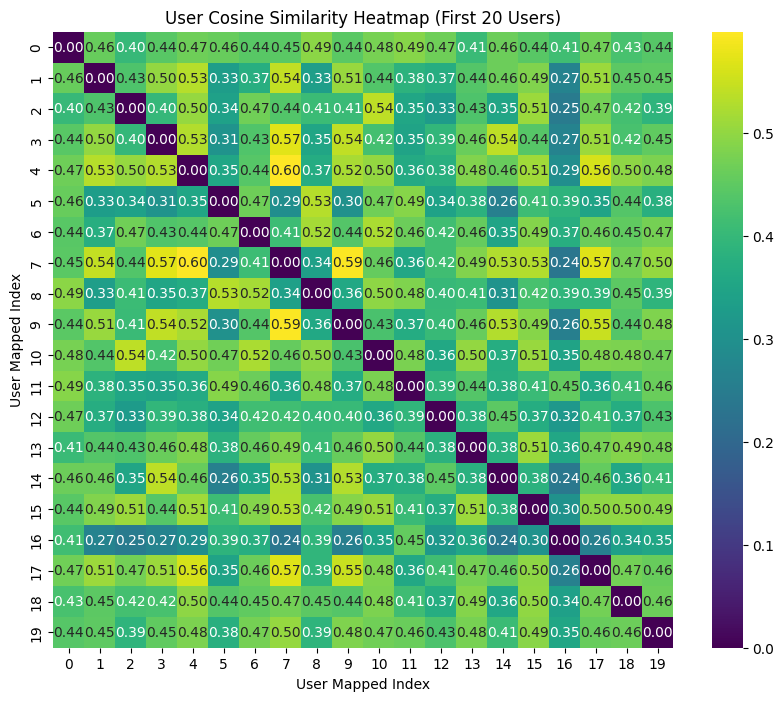

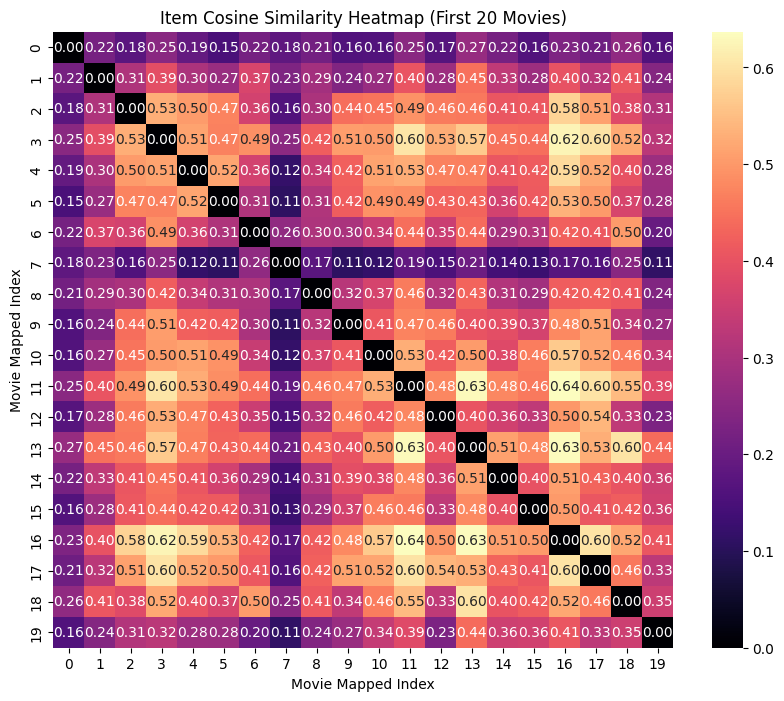

In [5]:
# User Similarity Heatmap (First 20 users)
plt.figure(figsize=(10, 8))
sns.heatmap(ucf.user_similarity[:20, :20], cmap='viridis', annot=True, fmt='.2f')
plt.title('User Cosine Similarity Heatmap (First 20 Users)')
plt.xlabel('User Mapped Index')
plt.ylabel('User Mapped Index')
plot1_path = os.path.join(config.REPORT_FIGS_DIR, '10_user_similarity_heatmap.png')
plt.savefig(plot1_path, dpi=150, bbox_inches='tight')
plt.show()

# Item Similarity Heatmap (First 20 movies)
plt.figure(figsize=(10, 8))
sns.heatmap(icf.item_similarity[:20, :20], cmap='magma', annot=True, fmt='.2f')
plt.title('Item Cosine Similarity Heatmap (First 20 Movies)')
plt.xlabel('Movie Mapped Index')
plt.ylabel('Movie Mapped Index')
plot2_path = os.path.join(config.REPORT_FIGS_DIR, '11_item_similarity_heatmap.png')
plt.savefig(plot2_path, dpi=150, bbox_inches='tight')
plt.show()